![](https://img.shields.io/badge/CNES_AVISO-Contribution-%20?color=grey&labelColor=blue)

# Altimetry Search

This notebook demonstrates how to search and select satellite altimetry passes (SWOT science and cal/val phases) by date and geographic area, using [Altimetry Search tool](https://github.com/CNES/altimetry-search)

## Use Altimetry Search Binder



Follow this [link](https://mybinder.org/v2/gh/CNES/altimetry-search/HEAD?urlpath=voila%2Frender%2Fmain.ipynb) to open Altimetry Search tool.

Use the top right dropdown list to select a mission (only Swot swath and Swot nadir available for now) and a period of interest. Then, with the left widget, select the area of interest (square icon). You can also use the + and - buttons to zoom in and out and wheel mouse to zoom in and out. Once you have selected the area of interest, click on the Search button to search for SWOT passes. The results are displayed in the table below and the swaths that intersect the area of interest are displayed on the map. Click on the marker to view the pass number.

You can draw multiple bounding boxes, but only the last one will be used for the search. You can also delete one or all bounding boxes by clicking on the trash icon.

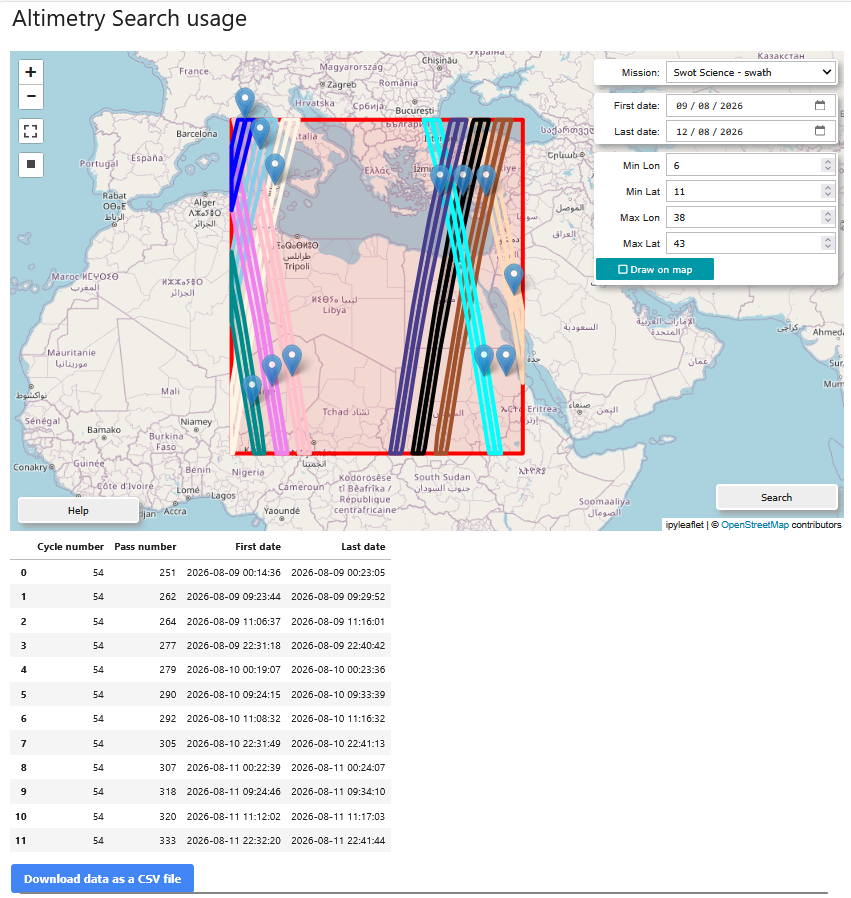

## Use of the Python API



```{note}

Required environment to run the following:

* ``altimetry-search``
* ``pyinterp``
* ``numpy``

In [1]:
import numpy
import pyinterp.geometry.geographic as py_geo
from altimetry.search import Mission, get_selected_passes, get_pass_passage_time, get_passes_crossing_polygon

In [2]:
import numpy
import pyinterp.geometry.geographic as py_geo
from altimetry.search import Mission, get_selected_passes, get_pass_passage_time, get_passes_crossing_polygon

mission = Mission.SWOT_SWATH_SCIENCE

# Search all passes starting within one cycle of a given date
selected_passes = get_selected_passes(
    mission,
    date=numpy.datetime64("2024-01-01"),
)
selected_passes

,cycle_number,pass_number,first_measurement,last_measurement
0,8,496,2023-12-14 06:49:20.010,2023-12-14 06:49:20.010
1,8,497,2023-12-14 06:49:20.010,2023-12-14 06:49:20.010
2,8,498,2023-12-14 06:49:20.010,2023-12-14 06:49:20.010
3,8,499,2023-12-14 06:49:20.010,2023-12-14 06:49:20.010
4,8,500,2023-12-14 06:49:20.010,2023-12-14 06:49:20.010
...,...,...,...,...
580,9,492,2024-01-04 03:34:26.795,2024-01-04 03:34:26.795
581,9,493,2024-01-04 03:34:26.795,2024-01-04 03:34:26.795
582,9,494,2024-01-04 03:34:26.795,2024-01-04 03:34:26.795
583,9,495,2024-01-04 03:34:26.795,2024-01-04 03:34:26.795


In [3]:
# Get the list of passes numbers intersecting a polygon
bbox = py_geo.algorithms.from_wkt(
    'POLYGON((-6 36,-6 60,36 60,36 36,-6 36))')

passes = numpy.array(sorted(set(selected_passes['pass_number'])))

passes_list = get_passes_crossing_polygon(
    mission=mission,
    polygon=bbox,
    passes=passes
)
passes_list

array([  1,  12,  14,  27,  29,  40,  42,  55,  57,  68,  70,  83,  85,
        96,  98, 111, 113, 124, 126, 139, 141, 150, 152, 167, 169, 178,
       180, 195, 197, 206, 208, 223, 225, 234, 236, 251, 253, 262, 264,
       277, 279, 290, 292, 305, 307, 318, 320, 333, 335, 346, 348, 361,
       363, 374, 376, 389, 391, 402, 404, 417, 419, 428, 430, 432, 445,
       447, 456, 458, 473, 475, 484, 486, 501, 503, 512, 514, 529, 531,
       540, 542, 555, 557, 559, 568, 570, 583], dtype=uint16)

In [4]:
# Restrict passes to those crossing a given area, and get the passage time
# window for each of them

passage_time = get_pass_passage_time(
    mission,
    selected_passes,
    polygon=bbox
)
passage_time

,pass_number,first_time,last_time
0,1,0 days 00:36:45.770050944,0 days 00:44:03.526295142
1,12,0 days 09:33:17.772689177,0 days 09:40:51.148614400
2,14,0 days 11:16:42.388172748,0 days 11:23:32.610013491
3,27,0 days 22:54:10.109774617,0 days 22:58:41.440314470
4,29,1 days 00:37:13.425947417,1 days 00:44:35.561036108
...,...,...,...
81,557,19 days 21:21:21.624684364,19 days 21:28:34.992193152
82,559,19 days 23:10:47.918689254,19 days 23:11:01.684500019
83,568,20 days 06:17:52.940961433,20 days 06:25:31.325494451
84,570,20 days 08:01:09.422523059,20 days 08:08:02.780811059
